In [1]:
import os
import pandas as pd
import glob

# 1. Update the path to match your screenshot
# It looks like: C:\Users\LENOVO\Desktop\EEG\SMNI_CMI_TRAIN
dataset_path = r'C:\Users\LENOVO\Desktop\EEG\SMNI_CMI_TRAIN'

def load_csv_data(root_dir):
    all_data_frames = []
    
    # This finds all files ending in .csv inside the folder
    csv_files = glob.glob(os.path.join(root_dir, "*.csv"))
    
    print(f"Found {len(csv_files)} CSV files in {root_dir}")
    
    for filename in csv_files:
        try:
            # Read the CSV file
            df_temp = pd.read_csv(filename)
            
            # (Optional) Add a column to track which file this data came from
            df_temp['original_file'] = os.path.basename(filename)
            
            all_data_frames.append(df_temp)
            
        except Exception as e:
            print(f"Error reading {os.path.basename(filename)}: {e}")

    if all_data_frames:
        # Combine all CSVs into one big DataFrame
        return pd.concat(all_data_frames, ignore_index=True)
    else:
        return pd.DataFrame()

# --- EXECUTION ---
if os.path.exists(dataset_path):
    print("Starting data loading...")
    df = load_csv_data(dataset_path)
    
    if not df.empty:
        print("✅ Loading complete.")
        print(f"Total Data Shape: {df.shape}")
        print("\nFirst 5 rows:")
        print(df.head())
    else:
        print("❌ No data loaded. Check if the folder is empty.")
else:
    print(f"❌ Directory not found: {dataset_path}")

Starting data loading...
Found 468 CSV files in C:\Users\LENOVO\Desktop\EEG\SMNI_CMI_TRAIN
✅ Loading complete.
Total Data Shape: (7667712, 11)

First 5 rows:
   Unnamed: 0  trial number sensor position  sample num  sensor value  \
0           5             0             FP1           0        -8.921   
1           6             0             FP1           1        -8.433   
2           7             0             FP1           2        -2.574   
3           8             0             FP1           3         5.239   
4           9             0             FP1           4        11.587   

  subject identifier matching condition  channel         name      time  \
0                  a             S1 obj        0  co2a0000364  0.000000   
1                  a             S1 obj        0  co2a0000364  0.003906   
2                  a             S1 obj        0  co2a0000364  0.007812   
3                  a             S1 obj        0  co2a0000364  0.011719   
4                  a        

In [2]:
# 1. Check if we have both 'a' (Alcoholic) and 'c' (Control) subjects
print("Classes found:", df['subject identifier'].unique())
print("\nClass distribution (rows per class):")
print(df['subject identifier'].value_counts())

# 2. Check the experimental conditions (S1 obj, S2 match, etc.)
# You might want to filter for just one condition later, or use all.
print("\nConditions found:", df['matching condition'].unique())

Classes found: ['a' 'c']

Class distribution (rows per class):
subject identifier
a    3850240
c    3817472
Name: count, dtype: int64

Conditions found: ['S1 obj' 'S2 nomatch,' 'S2 match']


In [3]:
# Group by Trial to see how many samples we have per experiment
# A "Trial" is defined by a unique combination of 'name' (subject) and 'trial number'
trial_counts = df.groupby(['name', 'trial number', 'matching condition']).size().reset_index(name='sample_count')

print("\n--- Trial Statistics ---")
print(f"Total number of unique trials (experiments): {len(trial_counts)}")
print(f"Average samples per trial: {trial_counts['sample_count'].mean()}")

# Check if all trials have the same length (Important for Neural Networks!)
print("\nUnique sample counts per trial:")
print(trial_counts['sample_count'].value_counts())


--- Trial Statistics ---
Total number of unique trials (experiments): 468
Average samples per trial: 16384.0

Unique sample counts per trial:
sample_count
16384    468
Name: count, dtype: int64


In [4]:
import numpy as np

def create_dataset(df):
    # 1. Create a unique identifier for each trial to group by
    # combining Subject Name + Trial Number
    df['trial_id'] = df['name'] + '_' + df['trial number'].astype(str)
    
    # Get unique trials
    trials = df['trial_id'].unique()
    print(f"Processing {len(trials)} trials...")
    
    X = []
    y = []
    
    # 2. Iterate through each trial to build the matrix
    # We use groupby because it's much faster than filtering the big DF repeatedly
    grouped = df.groupby('trial_id')
    
    for trial_id, group in grouped:
        
        # --- FEATURE MATRIX (X) ---
        # Pivot the data: 
        # Rows = Time Steps (sample num)
        # Cols = Channels (sensor position)
        # Values = Voltage (sensor value)
        pivot_data = group.pivot_table(index='sample num', 
                                       columns='sensor position', 
                                       values='sensor value')
        
        # The shape should be (256, 64)
        # We append this 2D matrix to our list
        X.append(pivot_data.values)
        
        # --- LABELS (y) ---
        # Get the label for this trial (a or c)
        # We take the first value since it's the same for the whole group
        label = group['subject identifier'].iloc[0]
        
        # Convert 'a' -> 1 (Alcoholic) and 'c' -> 0 (Control)
        if label == 'a':
            y.append(1)
        else:
            y.append(0)
            
    return np.array(X), np.array(y)

# --- EXECUTION ---
print("Reshaping data... (This might take 10-20 seconds)")
X, y = create_dataset(df)

print("\n✅ Data Preparation Complete!")
print(f"Feature Matrix (X) Shape: {X.shape}") # Should be (468, 256, 64)
print(f"Labels (y) Shape:         {y.shape}") # Should be (468,)

# Verify the balance
unique, counts = np.unique(y, return_counts=True)
print(f"Class Balance (0=Control, 1=Alcoholic): {dict(zip(unique, counts))}")

Reshaping data... (This might take 10-20 seconds)
Processing 468 trials...

✅ Data Preparation Complete!
Feature Matrix (X) Shape: (468, 256, 64)
Labels (y) Shape:         (468,)
Class Balance (0=Control, 1=Alcoholic): {np.int64(0): np.int64(233), np.int64(1): np.int64(235)}


In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GRU, Dropout, Conv1D, MaxPooling1D, BatchNormalization
from tensorflow.keras.optimizers import Adam

def build_gru_model(input_shape):
    model = Sequential()
    
    # --- CNN Block (Feature Extraction) ---
    model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.3)) 
    
    # --- GRU Block (Temporal Dynamics) ---
    model.add(GRU(64, return_sequences=False)) 
    model.add(Dropout(0.3))
    
    # --- Classification Head ---
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    
    return model

# --- EXECUTION ---
# Initialize the GRU model
model_gru = build_gru_model((256, 64))

# Compile
optimizer = Adam(learning_rate=0.001)
model_gru.compile(optimizer=optimizer, 
                  loss='binary_crossentropy', 
                  metrics=['accuracy'])

print("GRU Model Built Successfully:")
model_gru.summary()

c:\Users\LENOVO\anaconda3\envs\tf\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


GRU Model Built Successfully:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 254, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 127, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 127, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,681 (155.00 KB)

 Trainable params: 39,553 (154.50 KB)

 Non-trainable params: 128 (512.00 B)

In [7]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout, Conv1D, MaxPooling1D, BatchNormalization
from tensorflow.keras.optimizers import Adam

# 1. Stratified Split (80% Train, 20% Test)
# We use 'stratify=y' to ensure both sets keep the 50/50 balance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Training shape: {X_train.shape}")
print(f"Testing shape:  {X_test.shape}")

# 2. Define the Model Architecture
def build_model(input_shape):
    model = Sequential()
    
    # --- CNN Block (Feature Extraction) ---
    # Scans across the time steps to find local patterns
    model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.3)) # Prevent overfitting (crucial for small datasets like this)
    
    # --- LSTM Block (Temporal Dynamics) ---
    # Captures the sequence/history of the signal
    model.add(LSTM(64, return_sequences=False)) # False because we want one answer at the end
    model.add(Dropout(0.3))
    
    # --- Classification Head ---
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1, activation='sigmoid')) # Sigmoid for binary classification (0 or 1)
    
    return model

# Build and Compile
model = build_model((256, 64)) # (Time Steps, Channels)

optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, 
              loss='binary_crossentropy', 
              metrics=['accuracy'])

model.summary()

Training shape: (374, 256, 64)
Testing shape:  (94, 256, 64)


c:\Users\LENOVO\anaconda3\envs\tf\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 254, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 254, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 127, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 127, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,745 (186.50 KB)

 Trainable params: 47,617 (186.00 KB)

 Non-trainable params: 128 (512.00 B)


--- Training CNN-LSTM Model ---
Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.5829 - loss: 0.6761 - val_accuracy: 0.6277 - val_loss: 0.6452
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.6872 - loss: 0.6317 - val_accuracy: 0.6596 - val_loss: 0.6286
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.7032 - loss: 0.5694 - val_accuracy: 0.6596 - val_loss: 0.6126
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7567 - loss: 0.5085 - val_accuracy: 0.6915 - val_loss: 0.6697
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.8128 - loss: 0.4362 - val_accuracy: 0.7553 - val_loss: 0.5500
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.8690 - loss: 0.3557 - val_accuracy: 0.7340 - val_loss: 0.5890
Epoch 7/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.8850 - loss: 0.2901 - val_accuracy: 0.7872 - val_loss: 0.5206
Epoch 8/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.8556 - loss: 

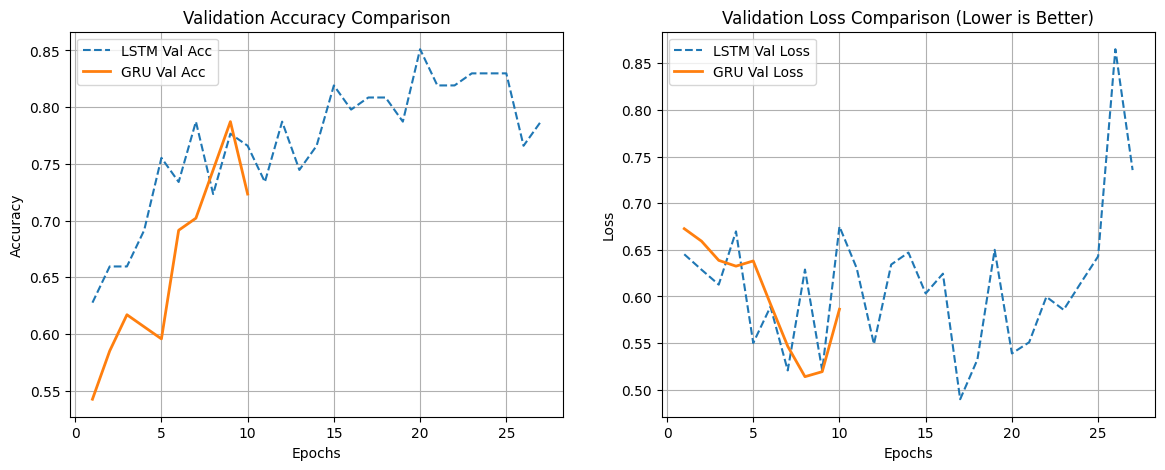


FINAL TEST RESULTS:
LSTM Accuracy: 80.85%
GRU Accuracy:  54.26%

🏆 Winner: LSTM performed better.


In [8]:
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping

# --- 1. CONFIGURATION ---
BATCH_SIZE = 16  # Small batch size is better for small datasets
EPOCHS = 50      # Maximum number of passes through the data

# Early Stopping: Stop training if validation loss doesn't improve for 10 epochs
# This prevents wasting time and overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# --- 2. TRAIN LSTM MODEL ---
print("\n--- Training CNN-LSTM Model ---")
# Re-build fresh model to ensure we start from scratch
model_lstm = build_model((256, 64)) 
model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_lstm = model_lstm.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)

# --- 3. TRAIN GRU MODEL ---
print("\n--- Training CNN-GRU Model ---")
model_gru = build_gru_model((256, 64))
model_gru.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_gru = model_gru.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)

# --- 4. COMPARISON PLOTS ---
def plot_comparison(h1, h2, name1="LSTM", name2="GRU"):
    acc1 = h1.history['val_accuracy']
    acc2 = h2.history['val_accuracy']
    loss1 = h1.history['val_loss']
    loss2 = h2.history['val_loss']
    
    epochs_range1 = range(1, len(acc1) + 1)
    epochs_range2 = range(1, len(acc2) + 1)

    plt.figure(figsize=(14, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range1, acc1, label=f'{name1} Val Acc', linestyle='--')
    plt.plot(epochs_range2, acc2, label=f'{name2} Val Acc', linewidth=2)
    plt.title('Validation Accuracy Comparison')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range1, loss1, label=f'{name1} Val Loss', linestyle='--')
    plt.plot(epochs_range2, loss2, label=f'{name2} Val Loss', linewidth=2)
    plt.title('Validation Loss Comparison (Lower is Better)')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.show()

print("\nGenerating comparison plots...")
plot_comparison(history_lstm, history_gru)

# --- 5. FINAL RESULTS ---
loss_lstm, acc_lstm = model_lstm.evaluate(X_test, y_test, verbose=0)
loss_gru, acc_gru = model_gru.evaluate(X_test, y_test, verbose=0)

print(f"\nFINAL TEST RESULTS:")
print(f"LSTM Accuracy: {acc_lstm*100:.2f}%")
print(f"GRU Accuracy:  {acc_gru*100:.2f}%")

if acc_gru > acc_lstm:
    print("\n🏆 Winner: GRU performed better.")
elif acc_lstm > acc_gru:
    print("\n🏆 Winner: LSTM performed better.")
else:
    print("\n🤝 It's a tie!")

--- Starting Stabilized Training ---


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, 254, 32)        │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 254, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 127, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 127, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,169 (59.25 KB)

 Trainable params: 15,105 (59.00 KB)

 Non-trainable params: 64 (256.00 B)

Epoch 1/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.5027 - loss: 2.2089 - val_accuracy: 0.4787 - val_loss: 2.2072 - learning_rate: 1.0000e-04
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.5000 - loss: 2.1690 - val_accuracy: 0.4787 - val_loss: 2.1679 - learning_rate: 1.0000e-04
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.4866 - loss: 2.1326 - val_accuracy: 0.5106 - val_loss: 2.1376 - learning_rate: 1.0000e-04
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.4733 - loss: 2.1364 - val_accuracy: 0.5000 - val_loss: 2.1080 - learning_rate: 1.0000e-04
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.5348 - loss: 2.0976 - val_accuracy: 0.4894 - val_loss: 2.0767 - learning_rate: 1.0000e-04
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.5428 - loss: 2.0594 - val_accuracy: 0.5000 - val_loss: 2.0460 - learning_rate: 1.0000e-04
Epoch 7/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 

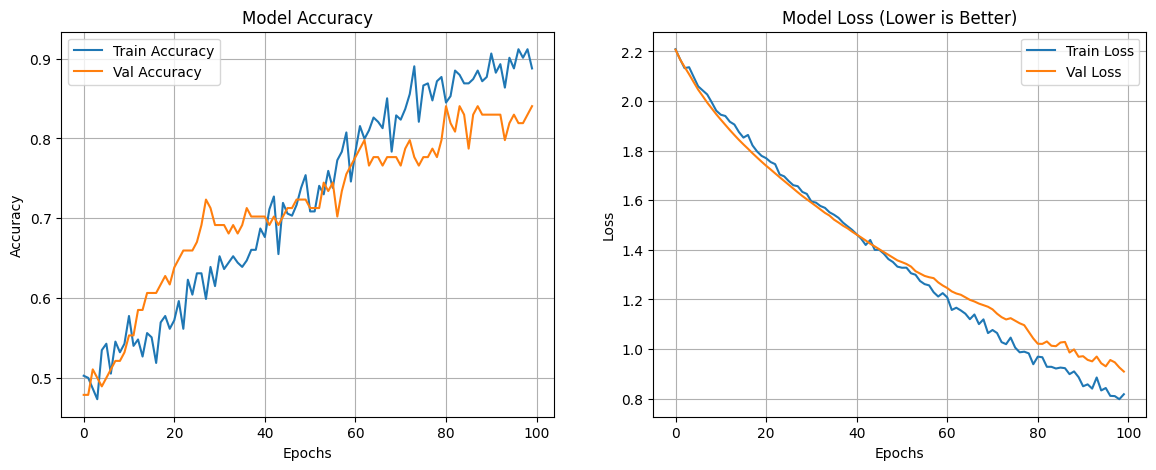


Final Test Accuracy: 84.04%


In [9]:
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout, Conv1D, MaxPooling1D, BatchNormalization, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 1. Define the Stabilized Architecture
def build_stabilized_lstm(input_shape):
    model = Sequential()
    
    # --- CNN Layer (Feature Extraction) ---
    # l2(0.01) penalizes large weights to prevent overfitting
    model.add(Conv1D(filters=32, kernel_size=3, activation='relu', 
                     kernel_regularizer=l2(0.01), input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.5)) # High dropout: turns off 50% of neurons randomly
    
    # --- LSTM Layer (Time Sequence) ---
    # Reduced units to 32 to keep the model lightweight
    model.add(LSTM(32, return_sequences=False, 
                   kernel_regularizer=l2(0.01), 
                   recurrent_regularizer=l2(0.01)))
    model.add(Dropout(0.5))
    
    # --- Classification Head ---
    model.add(Dense(16, activation='relu', kernel_regularizer=l2(0.01)))
    model.add(Dense(1, activation='sigmoid')) # Binary output (0 or 1)
    
    return model

# 2. Setup Training
input_shape = (256, 64) # (TimeSteps, Channels)
model = build_stabilized_lstm(input_shape)

# Use a lower learning rate (0.0001) for smoother convergence
optimizer = Adam(learning_rate=0.0001)

model.compile(optimizer=optimizer, 
              loss='binary_crossentropy', 
              metrics=['accuracy'])

# Callbacks to manage training automatically
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
]

print("--- Starting Stabilized Training ---")
model.summary()

# 3. Train
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100, # More epochs needed because of low learning rate + regularization
    batch_size=16,
    callbacks=callbacks,
    verbose=1
)

# 4. Plot Results
plt.figure(figsize=(14, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss (Lower is Better)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

# Final Evaluation
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nFinal Test Accuracy: {acc*100:.2f}%")